708024

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lab 6 - Fisher's Linear Discriminant and Logistic Regression
- For equations, refer to Bishop's book, Section 4.1.4 and the slides

# Part I - Fisher's Linear Discriminant for Binary Classification (2 classes)

## Data Generation and Visualisation
- First we'll use scikit-learn to generate 2 blobs of data in 2D, using the [make_blobs()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) function.
- The data consists of 600 points divided into 2 classes, 0 and 1.

In [65]:
from sklearn.datasets import make_blobs

In [66]:
X, y = make_blobs(n_samples=600, centers=2, n_features=2, random_state=0)

In [67]:
x0 = X[y == 1]
x1 = X[y == 0]

Let's confirm the data has two classes

In [68]:
np.unique(y)

array([0, 1])

## Exercise 1
- Now create a scatter plot to visualise the generated data. 
- Make sure to paint each point based on the class they belong to, as shown in the Figure below.

In [69]:
# your code goes here:


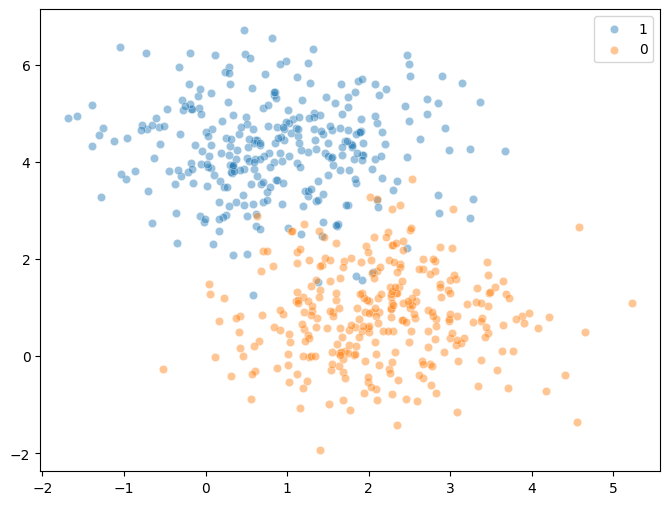

In [70]:
fig = plt.figure(figsize= (8,6))
sns.scatterplot(x = x1[:,0], y= x1[:,1], label= "1", alpha =0.45)
sns.scatterplot(x = x0[:,0], y= x0[:,1], label= "0", alpha =0.45)

m1 = np.array([x1[:,0].mean() , x1[:,1].mean()])
m0 = np.array([x0[:,0].mean() , x0[:,1].mean()])

plt.legend()


## Exercise 2
* Now plot a histogram of the data projected on each of the 2 dimensions of $X$ ($0$ and $1$)

As an example, below is a figure that shows the projection on dimension $1$.

_Tips:_ 
* You can either use `histplot()` to generate the plot, in which case it might be easier to pack $X$ and $y$ into a pandas DataFrame.
* Alternatively, considering that you will generate this plot many times throughout this lab, you can write a function that takes the projected vector and the class labels.
* Use 30 bins to obtain a similar plot.

In [71]:
def make_hist(vector, label):
    plt.figure(figsize= (8,6))
    sns.histplot(x= vector, hue= label, bins= 30)
    plt.legend(title = "class", labels= ["0", "1"])

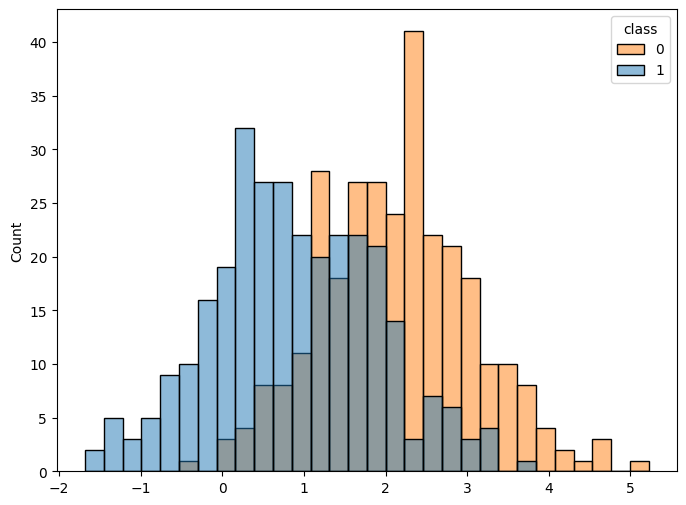

In [72]:
make_hist(X[:,0], y)

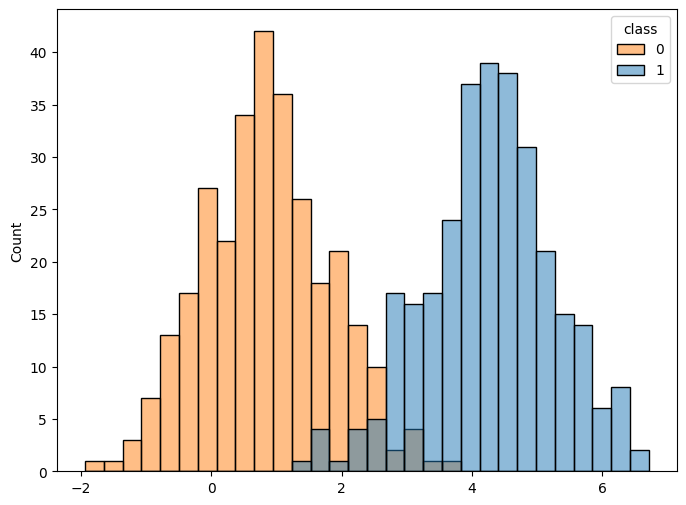

In [73]:
make_hist(X[:,1], y)

In [74]:
# your code goes here


## Exercise 3 - Implement Fisher's linear discriminant

* Use numpy to calculate $\vec{w}$.
* Plot the data (as you did in Exercise 1), and add a line on the direction of $\vec{w}$ (reference Figure below).
* Project the points onto the calculated vector, and plot the projection (as you did in Exercise 2) (reference Figure below).

In [75]:
def cov_matrix(x):
    m = x.mean(axis= 0)
    cov_m =  np.zeros((x.shape[1], x.shape[1]))
    
    for i in range(x.shape[0]):
        xn = (x[i]-m).reshape(-1,1)
        cov_m = cov_m + xn @ xn.T
        
    return cov_m

In [76]:
Sw = cov_matrix(x0) + cov_matrix(x1)
print(Sw)

[[567.71356713   2.77470709]
 [  2.77470709 573.46443367]]


In [77]:
w = np.linalg.inv(Sw)@(m1-m0)
w = w/np.linalg.norm(w)


In [78]:
x_ = np.linspace(-1000,500,200)

In [79]:
reta = np.outer(x_, w)


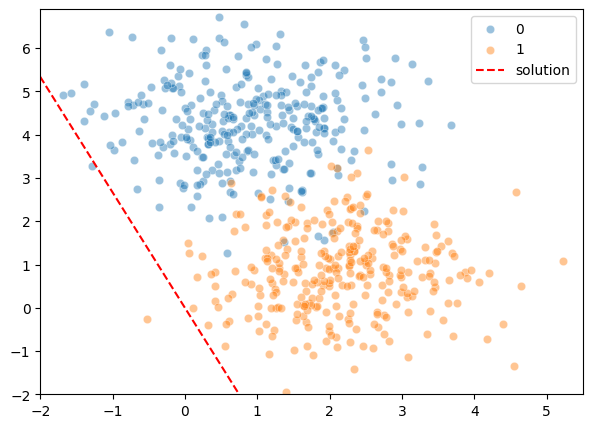

In [80]:
fig = plt.figure(figsize= (7,5))
sns.scatterplot(x = x1[:,0], y= x1[:,1], label= "0", alpha =0.45)
sns.scatterplot(x = x0[:,0], y= x0[:,1], label= "1", alpha =0.45)

m1 = np.array([x1[:,0].mean() , x1[:,1].mean()])
m0 = np.array([x0[:,0].mean() , x0[:,1].mean()])

sns.lineplot(x = reta[:,0], y= reta[:,1], color = "red", linestyle= "--", label= "solution")
plt.ylim(-2,6.9)
plt.xlim(-2,5.5)
plt.legend()


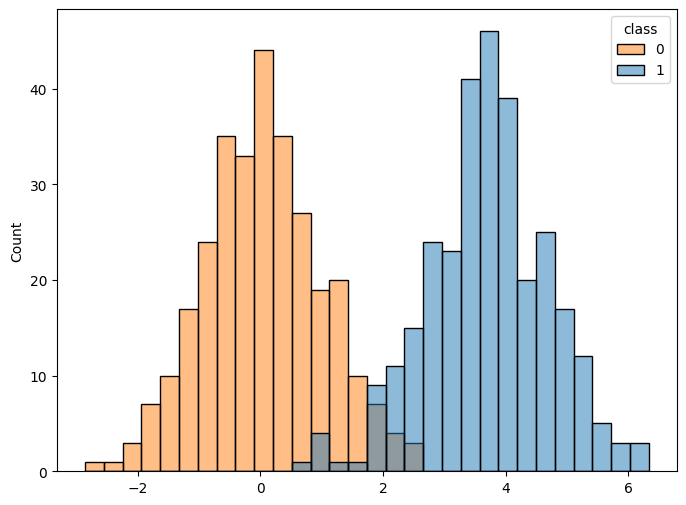

In [81]:
proj = X @ w

make_hist(proj, y)

## Exercise 4

* In this exercise you will use the `RidgeClassifier` from sklearn (as shown below) to obtain the class predictions from different types of projections:
    * component 0 of the data
    * component 1 of the data
    * the calculated vector $\vec{w}$
    
* Calculate the accuracy of these predictions using `accuracy_score` from sklearn.

In [82]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import RidgeClassifier

In [83]:
r = RidgeClassifier()
X0 = X[:,0].reshape(-1,1)
r.fit(X0, y)
predicted_y = r.predict(X0)
accuracy_0 = accuracy_score(predicted_y, y)

In [84]:
r = RidgeClassifier()
X1 = X[:,1].reshape(-1,1)
r.fit(X1, y)
predicted_y = r.predict(X1)
accuracy_1 = accuracy_score(predicted_y, y)

In [85]:
r = RidgeClassifier()
Xw = proj.reshape(-1,1)
r.fit(Xw, y)
predicted_y = r.predict(Xw)
accuracy = accuracy_score(predicted_y, y)

In [86]:
print(f"projection: first dimension, accuracy = {accuracy_0}")
print(f"projection: second dimension, accuracy = {accuracy_1}")
print(f"projection: Fisher's linear discriminant, accuracy = {accuracy}")

projection: first dimension, accuracy = 0.7366666666666667
projection: second dimension, accuracy = 0.955
projection: Fisher's linear discriminant, accuracy = 0.965


# Part II - Generalised Linear Discriminant (multi-class)

**NOTE:** For this part you will be using a multi-class estimator from scikit-learn (read the [documentation](https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda)).

## Exercise 1 - Generate data

* Generate a 3 classes dataset in 2D, with the same rules as before (make 300 points per class)
* Plot the data and then similar histograms (on each dimension) as Part I Exercises 1 and 2.

In [87]:
X, y = make_blobs(n_samples=900, centers=3, n_features=2, random_state=0)

In [88]:
X

array([[ 2.40808413,  0.74488924],
       [ 1.43368568,  3.33917531],
       [ 1.28933778,  3.44969159],
       ...,
       [-1.39499226,  0.93731667],
       [-2.13952975,  2.09505394],
       [ 1.37227679,  3.21072582]], shape=(900, 2))

In [89]:
np.unique(y)

array([0, 1, 2])

<Axes: >

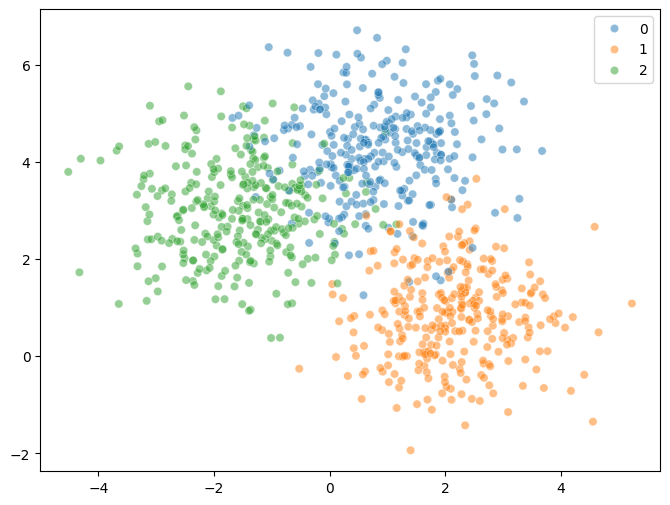

In [90]:
fig = plt.figure(figsize=(8,6))
sns.scatterplot(x= X[:,0], y= X[:,1], hue= y, palette= "tab10", alpha= 0.5)

In [91]:
def make_hist(vector, label):
    plt.figure(figsize= (8,6))
    sns.histplot(x= vector, hue= label, bins= 30)
    # plt.legend(title = "class", labels= ["2", "1", "0"])

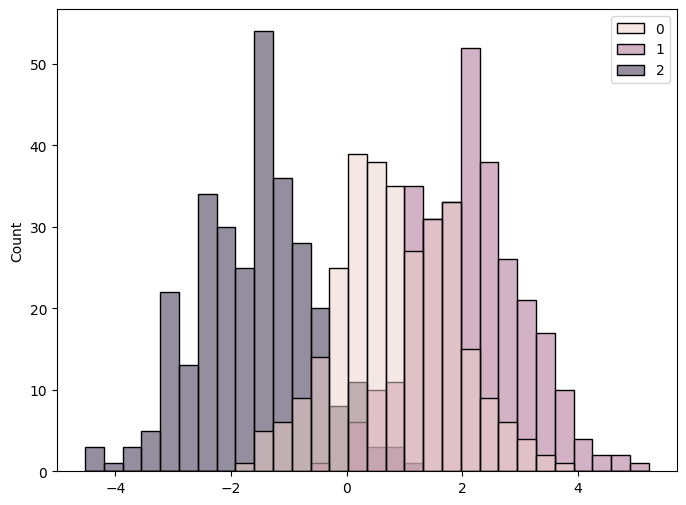

In [92]:
make_hist(X[:,0], y)

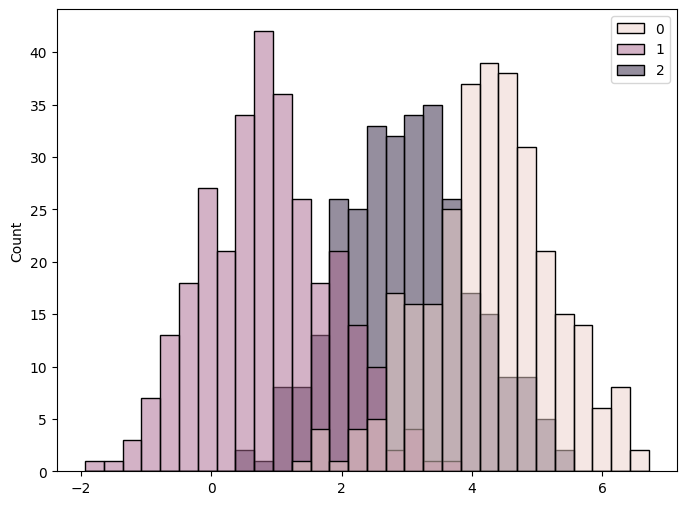

In [93]:
make_hist(X[:,1], y)

## Exercise 2 - Linear Discriminant Analysis

* Use sklearn's implementation of LDA to project the points in a single dimension and then plot the projected data

In [94]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Remember that since we want to project our data onto a vector, the parameter n_components of `LinearDiscriminantAnalysis` should be set to 1

In [95]:
lda = LinearDiscriminantAnalysis(n_components= 1)
lda.fit(X,y)
predicted_y = lda.predict(X)
proj_sklearn = lda.transform(X)

In [96]:
proj_sklearn.shape

(900, 1)

In [97]:
proj_sklearn = proj_sklearn.flatten()

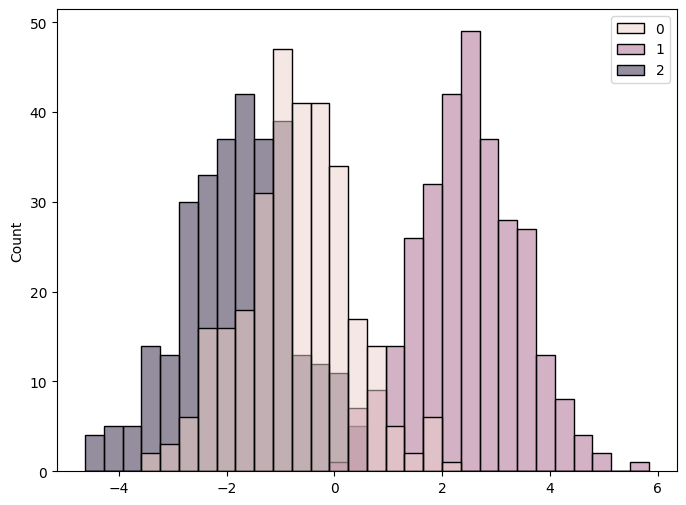

In [98]:
make_hist(proj_sklearn, y)

## Exercise 3 - Calculate test set accuracy

* use the default parameters for the LDA classifier, and report the prediction accuracy on a train/test split of 70/30% (use `random_state=0`)
* report also the accuracy of the `RidgeClassfier` you used in Part I 

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.7, random_state= 0)


In [101]:
lda.fit(X_train, y_train)
y_predicted_lda = lda.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_predicted_lda)

In [102]:
r.fit(X_train, y_train)
y_predicted_r = r.predict(X_test)
accuracy_r = accuracy_score(y_test, y_predicted_r)

In [103]:
print("Test Accuracies:")
print(f"LDA classifier: {accuracy_lda}")
print(f"Ridge Classifier fitting: {accuracy_r}")

Test Accuracies:
LDA classifier: 0.937037037037037
Ridge Classifier fitting: 0.9259259259259259
